**Lab Session 5** Grover's Algorithm


In [13]:
# librairies import
import numpy as np
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit_aer.noise import NoiseModel, pauli_error


**TODO1**
To mark a specific state (like '00' or '10'), we flip its sign (its phase). The main issue is that a multi-controlled phase gate only acts on the state where all qubits are 1. So we used X gates to temporarily transform our target state into an all-1s state. Then, we apply the multi-controlled phase gate to flip its sign. And then we apply the exact same X gates in reverse to undo the transformation and bring the state back to its original form (normal state). We repeat this logical block for each state present in the state_list.

In [3]:
def gen_oracle(qc, state_list):
    """
    Add an oracle to the quantum circuit to mark specified states.
    """
    num_qubits = qc.num_qubits
    
    # We do this for every state that should be marked (ex: '00', '10')
    for state in state_list:
        
        # Preparation
        # We apply a X gate on qubits corresponding to 0 in the state.

        for i, bit in enumerate(reversed(state)):
            if bit == '0':
                qc.x(i)
                
        # Marking
        # We apply a multi-control phase gate Z to multiply the amplitud by -1 when all qubits are 1.

        if num_qubits == 1:
            qc.z(0)
        else:
            controls = list(range(num_qubits - 1))
            target = num_qubits - 1
            
            qc.mcp(np.pi, controls, target)
            
        # Back to normal
        #We apply X gates where we first applied themto put qubits back in their original state.

        for i, bit in enumerate(reversed(state)):
            if bit == '0':
                qc.x(i)
                
    return qc

**TODO 2**
The diffusion operator amplifies the probability of finding our marked state by reflecting all amplitudes around their average. Its structure is always the same : a sequence of H, X, a multi-controlled Z then X and H again. We apply Hadamard and X gates to all qubits so that our multi-controlled phase gate can target the all-zero state instead of the all-ones state. Then, weapply the X and Hadamard gates again in reverse to complete the inversion.

In [4]:

def gen_diffusion(qc):
    """
    Applies Grover's diffusion operator to all qubits in the provided quantum circuit.
    """
    num_qubits = qc.num_qubits
    
    # We apply Hadamard gates to all qubits
    for i in range(num_qubits):
        qc.h(i)
        
    # We apply X gates to all qubits
    for i in range(num_qubits):
        qc.x(i)
        
    # We apply a Multi-Controlled Z gate
    if num_qubits == 1:
        qc.z(0)
    else:
        controls = list(range(num_qubits - 1))
        target = num_qubits - 1
        qc.mcp(np.pi, controls, target)
        
    # We apply X gates to all qubits again
    for i in range(num_qubits):
        qc.x(i)
        
    # We pply Hadamard gates to all qubits again
    for i in range(num_qubits):
        qc.h(i)
        
    return qc

**TODO3**
To run the noiseless simulation, the function ideal_sim creates a copy of the circuit and adds measurement gates to all qubits to be sure the original circuit can be used again later. It then uses Qiskit's aer_simulator to execute the circuit and get measurement counts.

In [5]:
def ideal_sim(qc):
    """
    Executes the given quantum circuit on a Aer simulator without noise
    and returns the measurements.
    """
    # We create a copy so we don't alter the original circuit with the measurements
    qc_measured = qc.copy()
    qc_measured.measure_all()
    
    # We the standard simulator (without noise)
    simulator = Aer.get_backend('aer_simulator')
    
    # We transpile to ensure compatibility
    compiled_circuit = transpile(qc_measured, simulator)
    
    # WE run the circuit 
    job = simulator.run(compiled_circuit, shots=1024)
    result = job.result()
    
    # We extract and return the counts
    counts = result.get_counts(compiled_circuit)
    return counts



For the test, we initialize 5 qubits in a full superposition then we apply our oracle to mark a chosen state and run the diffusion operator once. The resulting histogram plots the probabilities  showing an amplified peak for our targeted state

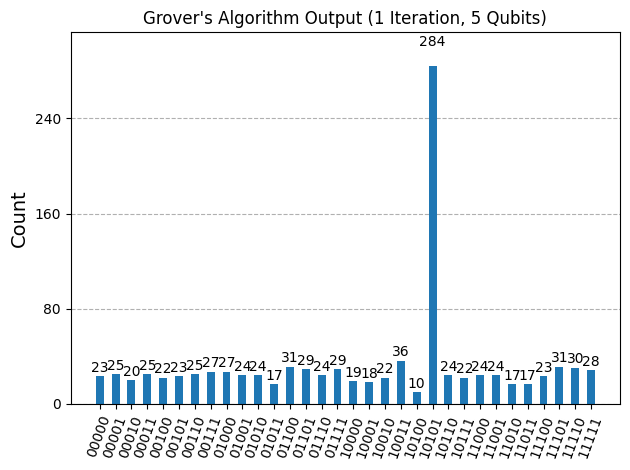

In [6]:
# TEST: Single Grover iteration on 5 qubits

n = 5
qc_grover = QuantumCircuit(n)

#Initialization : we put all qubits in a uniform superposition
for i in range(n):
    qc_grover.h(i)

#Oracle : we take for example '10101' as our secret state to find
secret_state = ['10101']
gen_oracle(qc_grover, secret_state)

#Diffusion : we amplify the probability of our secret state
gen_diffusion(qc_grover)

#Simulation and plotting
results = ideal_sim(qc_grover)
plot_histogram(results, title="Grover's Algorithm Output (1 Iteration, 5 Qubits)")
# plt.show()

**TODO 4**
To visualize the amplitudes, we use Statevector(qc) from qiskit.quantum_info to simulate the exact quantum state. To do that we require a circuit without measurement gates. Since our implementation of Grover's algorithm uses gates that do not introduce complex phases, we extract the real part of the state vector's data array. Then we plot these values as a bar chart against all possible binary basis states in order to track how the oracle flips amplitudes negative and how the diffusion operator amplifies them.

In [7]:
def plot_amplitudes(qc):
    """
    Calculates the exact state vector of the circuit (without measurements) and plots the amplitudes of each basis state.
    """
    # We extract the state vector from the quantum circuit
    state = Statevector(qc)
    
    #We extract the real part of the complex data array.
    amplitudes = np.real(state.data)
    
    #We generate binary labels for the x-axis based on the number of qubits
    num_qubits = qc.num_qubits
    labels = [format(i, f'0{num_qubits}b') for i in range(2**num_qubits)]
    
    #Creating the bar chart
    fig = plt.figure(figsize=(12, 6))
    plt.bar(labels, amplitudes, color='royalblue')
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.ylabel('Real Amplitude')
    plt.title(f"Statevector Amplitudes ({num_qubits} qubits)")

    return fig


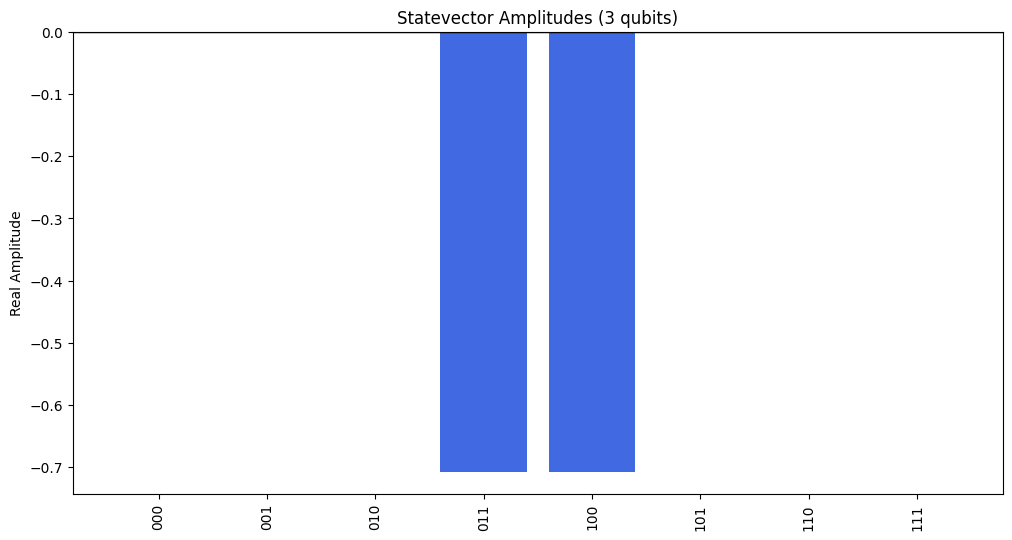

In [8]:
# TEST: Arbitrary states and qubits 


n_test = 3
qc_test = QuantumCircuit(n_test)

# Initialization
for i in range(n_test):
    qc_test.h(i)

# Oracle: marking two arbitrary states to verify the function works with a list
gen_oracle(qc_test, ['011', '100'])

# Diffusion
gen_diffusion(qc_test)

# Plot the amplitudes (No measurements added!)
fig = plot_amplitudes(qc_test)

**TODO 5**
To observe the overshooting effect of Grover's algorithm, we build by iteration and simulate circuits with an increasing number of full Grover steps by extracting only the amplitude of our marked state.

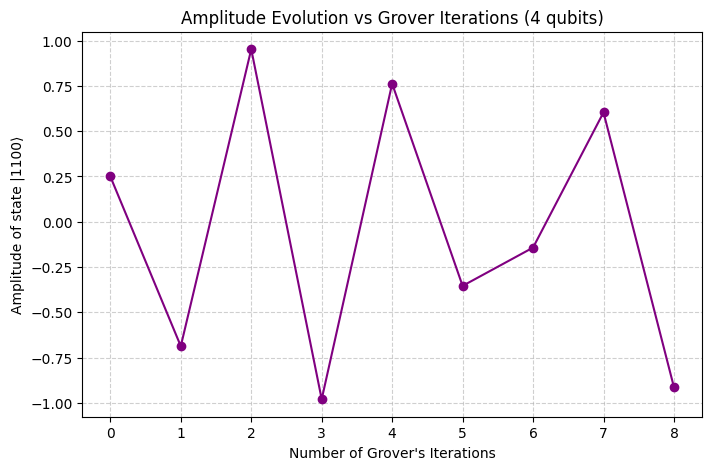

In [9]:
n_qubits = 4
# We pick an arbitrary state to search for
target_state = '1100' 
max_iterations = 8
amplitudes_over_time = []

# We test from 0 to 8 Grover iterations
for k in range(max_iterations + 1):
    qc = QuantumCircuit(n_qubits)
    
    # Initialization
    for i in range(n_qubits):
        qc.h(i)
        
    # We apply the Grover operator k times
    for _ in range(k):
        gen_oracle(qc, [target_state])
        gen_diffusion(qc)
        
    # We extract the exact state vector
    state = Statevector(qc)
    
    # Index of our target state
    target_index = int(target_state, 2)
    
    # Real amplitude
    amp = state.data[target_index].real
    amplitudes_over_time.append(amp)

fig = plt.figure(figsize=(8, 5))
plt.plot(range(max_iterations + 1), amplitudes_over_time, marker='o', color='purple')
plt.xlabel("Number of Grover's Iterations")
plt.ylabel(f"Amplitude of state |{target_state}⟩")
plt.title("Amplitude Evolution vs Grover Iterations (4 qubits)")
plt.grid(True, linestyle='--', alpha=0.6)

Looking at our plot, the amplitude reaches its absolute maximum at 3 iterations. At the 4th Grover step, the amplitude clearly begins to diminish, because the state vector has "rotated" past the optimal target axis.

**TODO 6**
We repeated the previous experiment by passing two target states to the oracle instead of one.


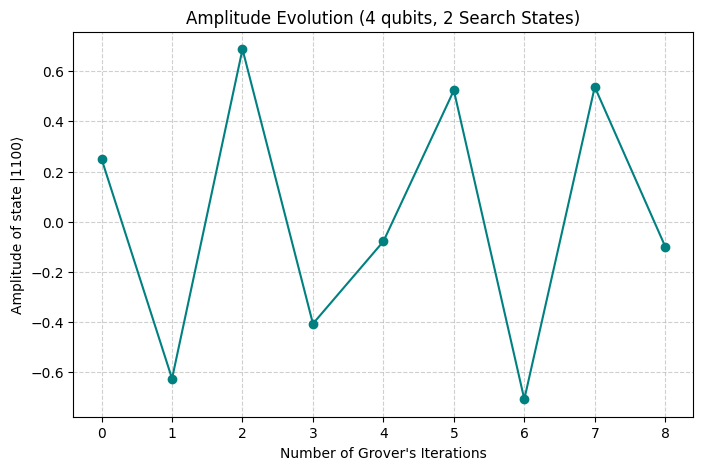

In [10]:
n_qubits = 4
# We now define two states to search for
target_states = ['1100', '0011'] 
max_iterations = 8

amplitudes_over_time = []

for k in range(max_iterations + 1):
    qc = QuantumCircuit(n_qubits)
    
    #Initialization
    for i in range(n_qubits):
        qc.h(i)
        
    #We apply the Grover operator k times
    for _ in range(k):
        # We pass both states to our oracle
        gen_oracle(qc, target_states)
        gen_diffusion(qc)
        
    state = Statevector(qc)
    
    #We only need to track the amplitude of the first one to see the trend due to simmetry.
    target_index = int(target_states[0], 2)
    amp = state.data[target_index].real
    amplitudes_over_time.append(amp)

#Results
fig = plt.figure(figsize=(8, 5))
plt.plot(range(max_iterations + 1), amplitudes_over_time, marker='o', color='teal')
plt.xlabel("Number of Grover's Iterations")
plt.ylabel(f"Amplitude of state |{target_states[0]}⟩")
plt.title("Amplitude Evolution (4 qubits, 2 Search States)")
plt.grid(True, linestyle='--', alpha=0.6)

By plotting the amplitudes for 2 target states, we observe the periodic nature of amplitude amplification. The amplitude peaks early (at 3 iterations) before overshooting and diminishing. Then it rotates back toward another peak later at the sixth iteration.

**TODO7**
We transpiled the 4-qubit circuit to match a cycle topology and a restricted gate set. 
The depth increases because the transpiler must break down our complex multi-controlled gates into many basic ones.
However a deeper circuit accumulates more individual gate errors and suffers from longer decoherence times  which will lead to the destruction of the amplified state in a noisy simulation

In [11]:

#We build a 4-qubit Grover circuit (1 iteration) for testing
n_qubits = 4
qc_ideal = QuantumCircuit(n_qubits)

for i in range(n_qubits):
    qc_ideal.h(i)
    
# Oracle and diffusion
gen_oracle(qc_ideal, ['1100'])
gen_diffusion(qc_ideal)

depth_before = qc_ideal.depth()

#Defining our hardware constraints
#0 connects to 1, 1 to 2, 2 to 3, and 3 back to 0.
# We add both directions so CNOTs can be applied either way.
my_coupling_map = [[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 0], [0, 3]]

# Restricted gate set allowed by the "hardware"
my_basis_gates = ['cx', 'rz', 'rx', 'h']

#Use the transpile function 
# # The transpiler will rewrite our ideal circuit using our constraints
qc_transpiled = transpile(qc_ideal, basis_gates=my_basis_gates, coupling_map=my_coupling_map, optimization_level=3)

depth_after = qc_transpiled.depth()

print(f"Circuit depth before transpilation: {depth_before}")
print(f"Circuit depth after transpilation: {depth_after}")

Circuit depth before transpilation: 9
Circuit depth after transpilation: 111


**TODO 8**
We created a Pauli error model for our transpiled gates. 
We tuned the noise to see the amplitude of our target state drop.

With an exponential noise model, errors multiply as the circuit gets deeper. Grover's algorithm needs multiple steps to work, but each step adds more noise. Eventually, the noise becomes so strong that adding more Grover steps actually ruins the result instead of improving it.

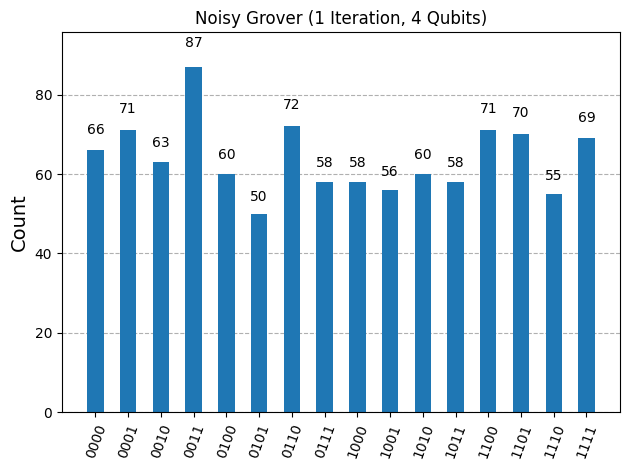

In [15]:
#Defining error probabilities
p_1q = 0.02 #2% error on 1-qubit gates
p_2q = 0.05 #5% error on 2-qubit gates

#We create Pauli-X errors
error_1q = pauli_error([('X', p_1q), ('I', 1 - p_1q)])
error_2q = error_1q.tensor(error_1q) # Combine two 1-qubit errors for the CNOT

#We build the noise model
noise_model = NoiseModel()
#We add the errors to the basis gates we used in transpilation
noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'rz', 'h'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

#Preparation of the transpiled circuit for measurement
qc_noisy = qc_transpiled.copy() 
qc_noisy.measure_all()

#Running the noisy simulation
simulator = Aer.get_backend('aer_simulator')
job_noisy = simulator.run(qc_noisy, noise_model=noise_model, shots=1024)
counts_noisy = job_noisy.result().get_counts()

#Results
plot_histogram(counts_noisy, title="Noisy Grover (1 Iteration, 4 Qubits)")

**TO DO 9**
We built a 40-qubit circuit with 20 Grover iterations and transpiled it for a cycle topology.

Circuit Depth: The depth of this circuit will be enormous. Breaking down 40-qubit multi-controlled gates into simple CNOTs and routing them through a ring topology requires massive amounts of gates.

However it is completely impossible to run this on today's noisy quantum computers without error correction. At huge depth the noise will completely destroy the quantum state long before the 20 iterations finish. The output would just be random garbage.

In [16]:
n_qubits = 40
iterations = 20

#We build the 40-qubit circuit
qc_40 = QuantumCircuit(n_qubits)

#Initialization
for i in range(n_qubits):
    qc_40.h(i)

#We apply 20 Grover iterations
for _ in range(iterations):
    controls = list(range(n_qubits - 1))
    target = n_qubits - 1
    qc_40.mcp(np.pi, controls, target)
    gen_diffusion(qc_40)

# We dfine the 40-qubit cycle topology
coupling_map_40 = []
for i in range(n_qubits):
    coupling_map_40.append([i, (i + 1) % n_qubits])
    coupling_map_40.append([(i + 1) % n_qubits, i])

basis_gates = ['cx', 'rz', 'rx', 'h']

#Transpile the circuit to get the depth
qc_transpiled_40 = transpile(qc_40, basis_gates=basis_gates, coupling_map=coupling_map_40, optimization_level=1)

print(f"Depth of the 40-qubit circuit: {qc_transpiled_40.depth()}")

Depth of the 40-qubit circuit: 1723145
